In [ ]:
#cell1
# Import required libraries
import json
import numpy as np
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import shutil
import warnings
warnings.filterwarnings('ignore')

print("\n✅ Libraries imported successfully")


✅ Libraries imported successfully


In [ ]:

# CELL 2: Mount Google Drive & Configure Paths
#----------------------------------------------------------------------------
# Mount Google Drive to access Phase 1B outputs
from google.colab import drive
drive.mount('/content/drive')

# CONFIGURATION - Update these paths to match your setup
PHASE1B_DATA_DIR = "/content/drive/MyDrive/ExamLens/phase1b_output/"# Phase 1B outputs
PHASE2_OUTPUT_DIR = "/content/drive/MyDrive/exam/examlens_phase2_events/"  # Where to save Phase 2 results
Path(PHASE2_OUTPUT_DIR).mkdir(exist_ok=True)

# Input files from Phase 1B (tracking data, motion scores, summary)
TRACKING_DATA_FILE = f"{PHASE1B_DATA_DIR}tracking_data.json"
MOTION_TIMELINE_FILE = f"{PHASE1B_DATA_DIR}motion_timeline.json"
SUMMARY_FILE = f"{PHASE1B_DATA_DIR}summary.json"
VIDEO_PATH = "/content/drive/MyDrive/ExamLens/videos/full_recording.mp4"  # Original video

print("\n📁 Configuration:")
print(f"   Phase 1B Data: {PHASE1B_DATA_DIR}")
print(f"   Phase 2 Output: {PHASE2_OUTPUT_DIR}")
print(f"   Video: {VIDEO_PATH}")

# Verify all input files exist before proceeding
print("\n🔍 Verifying input files:")
all_exist = True
for filepath in [TRACKING_DATA_FILE, MOTION_TIMELINE_FILE, SUMMARY_FILE]:
    exists = Path(filepath).exists()
    status = "✅" if exists else "❌"
    print(f"   {status} {Path(filepath).name}")
    if not exists:
        all_exist = False
        print(f"      Expected at: {filepath}")

if all_exist:
    print("\n✅ All input files found!")
else:
    print("\n⚠️  WARNING: Some files missing! Check paths above.")


Mounted at /content/drive

📁 Configuration:
   Phase 1B Data: /content/drive/MyDrive/ExamLens/phase1b_output/
   Phase 2 Output: /content/drive/MyDrive/exam/examlens_phase2_events/
   Video: /content/drive/MyDrive/ExamLens/videos/full_recording.mp4

🔍 Verifying input files:
   ✅ tracking_data.json
   ✅ motion_timeline.json
   ✅ summary.json

✅ All input files found!


In [ ]:
# CELL 2.5: Exam Type & Camera Configuration (NEW)
#----------------------------------------------------------------------------
# This cell allows the system to adapt detection based on exam type
# and physical camera setup for accurate distance measurements

print("\n" + "="*60)
print("📋 EXAM TYPE & CAMERA CONFIGURATION")
print("="*60)

# ====================
# EXAM TYPE SELECTION
# ====================
# Change this based on the type of exam being monitored
EXAM_TYPE = "PAPER_PEN"  # Options: "CBT", "PAPER_PEN", "PHYSICAL", "HYBRID"

# ====================
# CAMERA CALIBRATION
# ====================
# Physical parameters for converting pixels to real-world distances
CAMERA_CONFIG = {
    "height_cm": 250,           # Camera mounted2.5m above floor
    "angle_degrees": 30,        # Camera tilted 30° downward
    "fov_degrees": 90,          # 90° field of view
    "approx_distance_m": 5.0,   # Average distance from camera to students
    "pixels_per_meter": 200,    # Approximate scaling (adjust for your camera)
}

def pixels_from_cm(cm):
    """
    Convert physical distance (cm) to pixels based on camera calibration.
    This ensures detection thresholds are consistent across different cameras.
    """
    return int(cm / 100 * CAMERA_CONFIG['pixels_per_meter'])

# ====================
# EXAM TYPE PROFILES
# ====================
# Each exam type has different detection requirements
EXAM_PROFILES = {
    "CBT": {
        "description": "Computer-Based Test - Students use laptops throughout",
        "laptop_detection": False,        # Laptops are expected, don't flag
        "laptop_severity": "LOW",
        "movement_threshold": 0.85,# Very high (CBT students mostly still)
        "stillness_threshold": 0.10,      # Very low (typing = micro-movements)
        "proximity_cm": 75,
    },
    "PAPER_PEN": {
        "description": "Paper-Based Exam - No electronic devices allowed",
        "laptop_detection": True,         # ANY laptop use is suspicious
        "laptop_severity": "HIGH",
        "movement_threshold": 0.7,        # Normal writing movement
        "stillness_threshold": 0.15,      # Moderate stillness acceptable
        "proximity_cm": 75,
    },
    "PHYSICAL": {
        "description": "Physical Fitness Test - High movement expected",
        "laptop_detection": True,         # Devices suspicious during physical test
        "laptop_severity": "HIGH",
        "movement_threshold": 999,        # Disabled (movement is normal)
        "stillness_threshold": 0.20,
        "proximity_cm": 100,
    },
    "HYBRID": {
        "description": "Mixed Format Exam - Manual review recommended",
        "laptop_detection": True,
        "laptop_severity": "MEDIUM",
        "movement_threshold": 0.7,
        "stillness_threshold": 0.15,
        "proximity_cm": 75,
    }
}

# Load the selected exam profile
EXAM_PROFILE = EXAM_PROFILES.get(EXAM_TYPE, EXAM_PROFILES["HYBRID"])

# Display configuration summary
print(f"✅ Exam Type: {EXAM_TYPE}")
print(f"   📝 {EXAM_PROFILE['description']}")
print(f"\n⚙️  Detection Settings:")
print(f"   Laptop Detection: {'ENABLED' if EXAM_PROFILE['laptop_detection'] else 'DISABLED'}")
print(f"   Laptop Severity: {EXAM_PROFILE.get('laptop_severity', 'N/A')}")
print(f"   Movement Threshold: {EXAM_PROFILE['movement_threshold']}")
print(f"   Stillness Threshold: {EXAM_PROFILE['stillness_threshold']}")
print(f"\n📏 Physical Calibration:")
proximity_px = pixels_from_cm(EXAM_PROFILE['proximity_cm'])
print(f"   Proximity Threshold: {EXAM_PROFILE['proximity_cm']}cm (~{proximity_px}px)")
print(f"   Camera Height: {CAMERA_CONFIG['height_cm']}cm")
print("="*60)



📋 EXAM TYPE & CAMERA CONFIGURATION
✅ Exam Type: PAPER_PEN
   📝 Paper-Based Exam - No electronic devices allowed

⚙️  Detection Settings:
   Laptop Detection: ENABLED
   Laptop Severity: HIGH
   Movement Threshold: 0.7
   Stillness Threshold: 0.15

📏 Physical Calibration:
   Proximity Threshold: 75cm (~150px)
   Camera Height: 250cm


In [ ]:
# CELL 3: Event Detection Configuration (EXAM-AWARE - UPDATED)
#----------------------------------------------------------------------------
# Define detection parameters for each event type, adapted to exam type

# ====================
# EVENT CONFIGURATIONS
# ====================
EVENT_CONFIG = {
    # EVENT1: Laptop Interaction
    # Detects when person is near a laptop (unauthorized device use)
    "LAPTOP_INTERACTION": {
        "enabled": EXAM_PROFILE['laptop_detection'],  # Disabled for CBT exams
        "proximity_threshold": pixels_from_cm(EXAM_PROFILE['proximity_cm']),# 75cm in pixels
        "min_duration": 5.0,       # Minimum 5 seconds to flag
        "max_duration": 120.0,# Maximum 2 minutes (filters continuous exam use)
        "merge_gap": 10.0,         # Merge events within 10s of each other
        "severity": EXAM_PROFILE.get('laptop_severity', 'MEDIUM'),
        "color": "red" if EXAM_PROFILE.get('laptop_severity') == 'HIGH' else "orange",
        "description": f"Laptop interaction during {EXAM_TYPE} exam"
    },

    # EVENT 2: Suspicious Stillness
    # Detects prolonged stillness (potential hidden device usage like phone in lap)
    "SUSPICIOUS_STILLNESS": {
        "enabled": True,
        "motion_threshold": EXAM_PROFILE['stillness_threshold'],  # Motion score below this = still
        "min_duration": 10.0,      # Increased from 5s to reduce false positives (thinking)
        "merge_gap": 5.0,
        "severity": "HIGH",
        "color": "red",
        "description": "Prolonged suspicious stillness - potential hidden device usage"
    },

    # EVENT 3: Excessive Movement
    # Detects high movement (looking around, potential neighbor watching)
    "EXCESSIVE_MOVEMENT": {
        "enabled": EXAM_PROFILE['movement_threshold'] < 999,  # Disabled for physical tests
        "motion_threshold": EXAM_PROFILE['movement_threshold'],  # Motion score above this = excessive
        "min_duration": 15.0,      # Increased from 10s to reduce false positives (fidgeting)
        "merge_gap": 5.0,
        "severity": "MEDIUM",
        "color": "yellow",
        "description": "Sustained excessive movement detected"
    }
}

# Global settings
MIN_EVENT_CONFIDENCE = 0.6  # Filter events below 60% confidence
EVENT_MERGE_GAP_GLOBAL = 5.0  # Default gap for merging

# Display active configuration
print("⚙️  Event Detection Configuration:")
print("="*60)
print(f"\n🎯 Exam Type: {EXAM_TYPE}")
print(f"\n📋 Active Events:")
for event_type, config in EVENT_CONFIG.items():
    status = "✅ ENABLED" if config['enabled'] else "❌ DISABLED"
    print(f"   {event_type}: {status}")
    if config['enabled']:
        print(f"      Severity: {config['severity']}, Min Duration: {config['min_duration']}s")

if EXAM_TYPE == "CBT":
    print("\n💡 Note: Laptop detection disabled (continuous use expected in CBT)")
elif EXAM_TYPE == "PHYSICAL":
    print("\n💡 Note: Movement detection disabled (high activity expected)")

print("\n" + "="*60)


⚙️  Event Detection Configuration:

🎯 Exam Type: PAPER_PEN

📋 Active Events:
   LAPTOP_INTERACTION: ✅ ENABLED
      Severity: HIGH, Min Duration: 5.0s
   SUSPICIOUS_STILLNESS: ✅ ENABLED
      Severity: HIGH, Min Duration: 10.0s
   EXCESSIVE_MOVEMENT: ✅ ENABLED
      Severity: MEDIUM, Min Duration: 15.0s



In [ ]:
# CELL 4: Load Phase 1B Data with Adaptive Frame Skip (COMPLETE FINAL)
#----------------------------------------------------------------------------
print("\n📂 Loading Phase 1B tracking data...")
print("="*60)

# Load frame-by-frame tracking data
with open(TRACKING_DATA_FILE, 'r') as f:
    tracking_data = json.load(f)
print(f"✅ Tracking data: {len(tracking_data)} frames loaded")

# ====================
# CALCULATE VIDEO DURATION
# ====================
if len(tracking_data) > 0:
    video_duration_seconds = tracking_data[-1]['timestamp']
    video_duration_minutes = video_duration_seconds / 60
    video_duration_hours = video_duration_minutes / 60
else:
    video_duration_seconds = 0
    video_duration_minutes = 0
    video_duration_hours = 0

print(f"📹 Video duration: {video_duration_minutes:.1f} minutes ({video_duration_hours:.2f} hours)")
print(f"📹 Total frames: {len(tracking_data):,}")

# ====================
# ADAPTIVE FRAME SKIP
# ====================
# Automatically adjust based on video duration
# Short videos = minimal skip (high accuracy)
# Long videos = aggressive skip (fast processing)

if video_duration_minutes <= 5:
    FRAME_SKIP_PHASE2 = 3 # Very short video (1-5 min)
    target_time = "1-2 min"
    accuracy_estimate = "~95%"
elif video_duration_minutes <= 15:
    FRAME_SKIP_PHASE2 = 6       # Short video (5-15 min)
    target_time = "3-5 min"
    accuracy_estimate = "~92%"
elif video_duration_minutes <= 30:
    FRAME_SKIP_PHASE2 = 12      # Medium video (15-30 min)
    target_time = "8-12 min"
    accuracy_estimate = "~88%"
else:
    FRAME_SKIP_PHASE2 = 18      # Long video (30+ min,2+ hours)
    target_time = "15-25 min"
    accuracy_estimate = "~85%"

print(f"\n⚡ ADAPTIVE FRAME SKIP ENABLED")
print(f"   Video category: {'Very Short' if video_duration_minutes <= 5 else 'Short' if video_duration_minutes <= 15 else 'Medium' if video_duration_minutes <= 30 else 'Long'}")
print(f"   Selected skip: Every {FRAME_SKIP_PHASE2} frames")
print(f"   Expected Phase 2 time: {target_time}")
print(f"   Expected accuracy: {accuracy_estimate}")

# ====================
# APPLY FRAME SKIP
# ====================
if FRAME_SKIP_PHASE2 > 1:
    tracking_data_filtered = tracking_data[::FRAME_SKIP_PHASE2]
    frames_before = len(tracking_data)
    frames_after = len(tracking_data_filtered)

    print(f"\n📊 Frame Skip Results:")
    print(f"   Original frames: {frames_before:,}")
    print(f"   Processing frames: {frames_after:,}")
    print(f"   Speedup: {frames_before/frames_after:.1f}x faster")
    print(f"   Time saved: ~{(1 - 1/(frames_before/frames_after))*100:.0f}%")

    tracking_data = tracking_data_filtered
else:
    print("\n   No frame skip applied (processing all frames)")

# ====================
# LOAD MOTION TIMELINE
# ====================
with open(MOTION_TIMELINE_FILE, 'r') as f:
    motion_timeline = json.load(f)
print(f"\n✅ Motion timeline: {len(motion_timeline)} persons tracked")

# ====================
# LOAD SUMMARY
# ====================
with open(SUMMARY_FILE, 'r') as f:
    summary = json.load(f)
print(f"✅ Summary: {summary['total_detections']} total detections")

# ====================
# BUILD PERSON TRACKING INDEX
# ====================
# Structure: {person_id: [list of frame detections]}
person_tracks = defaultdict(list)
for frame_data in tracking_data:
    for det in frame_data['detections']:
        if det['class'] == 'person':
            person_tracks[det['track_id']].append({
                'frame': frame_data['frame'],
                'timestamp': frame_data['timestamp'],
                'bbox': det['bbox'],
                'motion_score': det.get('motion_score', 0.0),})

print(f"✅ Indexed {len(person_tracks)} unique persons")

# ====================
# DISPLAY SAMPLE TRACKS
# ====================
print(f"\n📊 Sample person tracks:")
sample_count = 0
for person_id in sorted(person_tracks.keys()):
    if sample_count >= 5:
        break
    track_length = len(person_tracks[person_id])
    if track_length > 0:
        duration = (person_tracks[person_id][-1]['timestamp'] -
                   person_tracks[person_id][0]['timestamp'])
        print(f"   Person {person_id}: {track_length} detections over {duration:.1f}s")
        sample_count += 1

if len(person_tracks) > 5:
    print(f"   ... and {len(person_tracks) - 5} more persons")

# ====================
# SUMMARY
# ====================
print("\n" + "="*60)
print("✅ DATA LOADED & INDEXED SUCCESSFULLY!")
print("="*60)
print(f"📊 Processing Summary:")
print(f"   Video: {video_duration_minutes:.1f} min")
print(f"   Frames: {len(tracking_data):,} (from {frames_before:,})")
print(f"   Persons: {len(person_tracks)}")
print(f"   Frame skip: {FRAME_SKIP_PHASE2}x")
print(f"   Expected time: {target_time}")
print("="*60)



📂 Loading Phase 1B tracking data...
✅ Tracking data: 177363 frames loaded
📹 Video duration: 134.4 minutes (2.24 hours)
📹 Total frames: 177,363

⚡ ADAPTIVE FRAME SKIP ENABLED
   Video category: Long
   Selected skip: Every 18 frames
   Expected Phase 2 time: 15-25 min
   Expected accuracy: ~85%

📊 Frame Skip Results:
   Original frames: 177,363
   Processing frames: 9,854
   Speedup: 18.0x faster
   Time saved: ~94%

✅ Motion timeline: 2603 persons tracked
✅ Summary: 519102 total detections
✅ Indexed 1674 unique persons

📊 Sample person tracks:
   Person 1: 6 detections over 4.1s
   Person 2: 231 detections over 193.1s
   Person 3: 14 detections over 12.3s
   Person 4: 4 detections over 3.3s
   Person 5: 5 detections over 3.3s
   ... and 1669 more persons

✅ DATA LOADED & INDEXED SUCCESSFULLY!
📊 Processing Summary:
   Video: 134.4 min
   Frames: 9,854 (from 177,363)
   Persons: 1674
   Frame skip: 18x
   Expected time: 15-25 min


In [ ]:

# CELL 5: Helper Functions (COMPLETE)
#----------------------------------------------------------------------------

def calculate_distance(bbox1, bbox2):
    """Calculate distance between bbox centers."""
    cx1 = (bbox1[0] + bbox1[2]) / 2
    cy1 = (bbox1[1] + bbox1[3]) / 2
    cx2 = (bbox2[0] + bbox2[2]) / 2
    cy2 = (bbox2[1] + bbox2[3]) / 2
    return np.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)


def calculate_bbox_aspect_ratio(bbox):
    """Calculate bbox aspect ratio (height/width)."""
    width = bbox[2] - bbox[0]
    height = bbox[3] - bbox[1]
    return height / width if width > 0 else 1.0


def calculate_event_confidence(event_type, duration, signal_strength):
    """Calculate confidence score for an event."""
    base_confidence = signal_strength
    duration_bonus = min(0.2, duration / 50.0)

    type_multipliers = {
        'LAPTOP_INTERACTION': 0.85,
        'SUSPICIOUS_STILLNESS': 0.9,
        'EXCESSIVE_MOVEMENT': 0.75
    }

    multiplier = type_multipliers.get(event_type, 0.8)
    confidence = (base_confidence + duration_bonus) * multiplier
    return min(1.0, max(0.0, confidence))


def merge_consecutive_events(events, max_gap=5.0):
    """Merge events of same type close in time."""
    if len(events) == 0:
        return []

    events = sorted(events, key=lambda x: x['start_time'])
    merged = []
    current = events[0].copy()

    for event in events[1:]:
        gap = 10.0 if event['event_type'] == 'LAPTOP_INTERACTION' else max_gap

        if (event['event_type'] == current['event_type'] and
            event['person_id'] == current['person_id'] and
            event['start_time'] - current['end_time'] <= gap):
            current['end_time'] = event['end_time']
            current['duration'] = current['end_time'] - current['start_time']
            current['confidence'] = max(current['confidence'], event['confidence'])
        else:
            merged.append(current)
            current = event.copy()

    merged.append(current)
    return merged


def format_timestamp(seconds):
    """Convert seconds to MM:SS format."""
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{mins:02d}:{secs:02d}"


print("✅ Helper functions defined")


✅ Helper functions defined


In [ ]:
# CELL 6: Detect Laptop Interaction Events
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔍 DETECTING LAPTOP INTERACTION EVENTS")
print("="*60)

all_events = []
config = EVENT_CONFIG['LAPTOP_INTERACTION']

if config['enabled']:
    laptop_interactions = []

    for frame_data in tqdm(tracking_data, desc="Scanning laptop interactions"):
        persons = [d for d in frame_data['detections'] if d['class'] == 'person']
        laptops = [d for d in frame_data['detections'] if d['class'] == 'laptop']

        for person in persons:
            for laptop in laptops:
                distance = calculate_distance(person['bbox'], laptop['bbox'])

                if distance < config['proximity_threshold']:
                    laptop_interactions.append({
                        'frame': frame_data['frame'],
                        'timestamp': frame_data['timestamp'],
                        'person_id': person['track_id'],
                        'distance': distance
                    })

    print(f"\n📊 Found {len(laptop_interactions)} frame-level interactions")

    if len(laptop_interactions) > 0:
        person_interactions = defaultdict(list)
        for interaction in laptop_interactions:
            person_interactions[interaction['person_id']].append(interaction)

        for person_id, interactions in person_interactions.items():
            interactions = sorted(interactions, key=lambda x: x['timestamp'])

            start_time = interactions[0]['timestamp']
            end_time = interactions[0]['timestamp']
            for i in range(1, len(interactions)):
                gap = interactions[i]['timestamp'] - end_time

                if gap <= config['merge_gap']:
                    end_time = interactions[i]['timestamp']
                else:
                    duration = end_time - start_time
                    if config['min_duration'] <= duration <= config['max_duration']:
                        all_events.append({
                            'event_type': 'LAPTOP_INTERACTION',
                            'person_id': person_id,
                            'start_time': start_time,
                            'end_time': end_time,
                            'duration': duration,
                            'severity': config['severity'],
                            'confidence': calculate_event_confidence('LAPTOP_INTERACTION', duration,0.85),
                            'description': config['description']
                        })
                    start_time = interactions[i]['timestamp']
                    end_time = interactions[i]['timestamp']

            duration = end_time - start_time
            if config['min_duration'] <= duration <= config['max_duration']:
                all_events.append({
                    'event_type': 'LAPTOP_INTERACTION',
                    'person_id': person_id,
                    'start_time': start_time,
                    'end_time': end_time,
                    'duration': duration,
                    'severity': config['severity'],
                    'confidence': calculate_event_confidence('LAPTOP_INTERACTION', duration, 0.85),
                    'description': config['description']
                })

    laptop_count = len([e for e in all_events if e['event_type'] == 'LAPTOP_INTERACTION'])
    print(f"✅ Detected {laptop_count} LAPTOP_INTERACTION events")
else:
    print("⏭️  LAPTOP_INTERACTION detection disabled for this exam type")



🔍 DETECTING LAPTOP INTERACTION EVENTS


Scanning laptop interactions: 100%|██████████| 9854/9854 [00:00<00:00, 155240.15it/s]


📊 Found 255 frame-level interactions
✅ Detected 17 LAPTOP_INTERACTION events


In [ ]:
# CELL 7: Detect Suspicious Stillness Events
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔍 DETECTING SUSPICIOUS STILLNESS EVENTS")
print("="*60)

config = EVENT_CONFIG['SUSPICIOUS_STILLNESS']

if config['enabled']:
    for person_id, track in person_tracks.items():
        if len(track) < 2:
            continue

        still_start = None
        still_duration = 0

        for detection in track:
            motion = detection['motion_score']

            if motion < config['motion_threshold']:
                if still_start is None:
                    still_start = detection['timestamp']
                still_duration = detection['timestamp'] - still_start
            else:
                if still_start is not None and still_duration >= config['min_duration']:
                    all_events.append({
                        'event_type': 'SUSPICIOUS_STILLNESS',
                        'person_id': person_id,
                        'start_time': still_start,
                        'end_time': still_start + still_duration,
                        'duration': still_duration,
                        'severity': config['severity'],
                        'confidence': calculate_event_confidence('SUSPICIOUS_STILLNESS', still_duration, 0.8),
                        'description': config['description']
                    })
                still_start = None
                still_duration = 0

        if still_start is not None and still_duration >= config['min_duration']:
            all_events.append({
                'event_type': 'SUSPICIOUS_STILLNESS',
                'person_id': person_id,
                'start_time': still_start,
                'end_time': still_start + still_duration,
                'duration': still_duration,
                'severity': config['severity'],
                'confidence': calculate_event_confidence('SUSPICIOUS_STILLNESS', still_duration, 0.8),
                'description': config['description']
            })

    stillness_count = len([e for e in all_events if e['event_type'] == 'SUSPICIOUS_STILLNESS'])
    print(f"✅ Detected {stillness_count} SUSPICIOUS_STILLNESS events")
else:
    print("⏭️  SUSPICIOUS_STILLNESS detection disabled")



🔍 DETECTING SUSPICIOUS STILLNESS EVENTS
✅ Detected 279 SUSPICIOUS_STILLNESS events


In [ ]:

# CELL 8: Detect Excessive Movement Events
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔍 DETECTING EXCESSIVE MOVEMENT EVENTS")
print("="*60)

config = EVENT_CONFIG['EXCESSIVE_MOVEMENT']

if config['enabled']:
    for person_id, track in person_tracks.items():
        if len(track) < 2:
            continue

        movement_start = None
        movement_duration = 0

        for detection in track:
            motion = detection['motion_score']

            if motion > config['motion_threshold']:
                if movement_start is None:
                    movement_start = detection['timestamp']
                movement_duration = detection['timestamp'] - movement_start
            else:
                if movement_start is not None and movement_duration >= config['min_duration']:
                    all_events.append({
                        'event_type': 'EXCESSIVE_MOVEMENT',
                        'person_id': person_id,
                        'start_time': movement_start,
                        'end_time': movement_start + movement_duration,
                        'duration': movement_duration,
                        'severity': config['severity'],
                        'confidence': calculate_event_confidence('EXCESSIVE_MOVEMENT', movement_duration, 0.7),
                        'description': config['description']
                    })

                movement_start = None
                movement_duration = 0

        if movement_start is not None and movement_duration >= config['min_duration']:
            all_events.append({
                'event_type': 'EXCESSIVE_MOVEMENT',
                'person_id': person_id,
                'start_time': movement_start,
                'end_time': movement_start + movement_duration,
                'duration': movement_duration,
                'severity': config['severity'],
                'confidence': calculate_event_confidence('EXCESSIVE_MOVEMENT', movement_duration, 0.7),
                'description': config['description']
            })

    movement_count = len([e for e in all_events if e['event_type'] == 'EXCESSIVE_MOVEMENT'])
    print(f"✅ Detected {movement_count} EXCESSIVE_MOVEMENT events")
else:
    print("⏭️  EXCESSIVE_MOVEMENT detection disabled for this exam type")



🔍 DETECTING EXCESSIVE MOVEMENT EVENTS
✅ Detected 7 EXCESSIVE_MOVEMENT events


In [ ]:
# CELL 9: Merge & Filter Events
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔧 MERGING & FILTERING EVENTS")
print("="*60)

print(f"\n📊 Before merging: {len(all_events)} events")

# Merge consecutive events of same type
all_events = merge_consecutive_events(all_events, max_gap=EVENT_MERGE_GAP_GLOBAL)

print(f"📊 After merging: {len(all_events)} events")

# Filter by confidence
filtered_events = [e for e in all_events if e['confidence'] >= MIN_EVENT_CONFIDENCE]

print(f"📊 After confidence filter (>={MIN_EVENT_CONFIDENCE}): {len(filtered_events)} events")

# Sort by severity then time
severity_order = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
filtered_events = sorted(filtered_events, key=lambda x: (severity_order.get(x['severity'], 3), x['start_time']))

# Assign event IDs and formatted timestamps
for i, event in enumerate(filtered_events, 1):
    event['event_id'] = i
    event['start_time_formatted'] = format_timestamp(event['start_time'])
    event['end_time_formatted'] = format_timestamp(event['end_time'])

print(f"\n✅ Final event count: {len(filtered_events)}")

# Summary by type
event_summary = defaultdict(int)
for event in filtered_events:
    event_summary[event['event_type']] += 1

print(f"\n📊 Events by type:")
for event_type, count in sorted(event_summary.items(), key=lambda x: x[1], reverse=True):
    print(f"{event_type}: {count}")

# Summary by severity
severity_summary = defaultdict(int)
for event in filtered_events:
    severity_summary[event['severity']] += 1

print(f"\n📊 Events by severity:")
for severity in ['HIGH', 'MEDIUM', 'LOW']:
    count = severity_summary.get(severity, 0)
    print(f"   {severity}: {count}")




🔧 MERGING & FILTERING EVENTS

📊 Before merging: 303 events
📊 After merging: 283 events
📊 After confidence filter (>=0.6): 283 events

✅ Final event count: 283

📊 Events by type:
SUSPICIOUS_STILLNESS: 259
LAPTOP_INTERACTION: 17
EXCESSIVE_MOVEMENT: 7

📊 Events by severity:
   HIGH: 276
   MEDIUM: 7
   LOW: 0


In [ ]:




# CELL 9.5: Adaptive Merging for Long Videos (NEW)
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔧 ADAPTIVE MERGING (Reduces over-segmentation)")
print("="*60)

# For long videos, apply more aggressive merging
if len(tracking_data) > 10000:  # >10k frames (~14 min at 12fps)
    print("   Long video detected - applying aggressive merging")
    original_count = len(filtered_events)
    filtered_events = merge_consecutive_events(filtered_events, max_gap=15.0)
    reduced_count = original_count - len(filtered_events)
    print(f"   Merged {reduced_count} additional events")
    print(f"   Final count: {len(filtered_events)} events")
else:
    print("   Standard merging applied (video < 14 minutes)")

print("="*60)




🔧 ADAPTIVE MERGING (Reduces over-segmentation)
   Standard merging applied (video < 14 minutes)


In [ ]:

# CELL 9.9: Per-Person Baseline Calibration (NEW)
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("📊 PER-PERSON BASELINE CALIBRATION")
print("="*60)

def calculate_person_baseline(person_tracks):
    """Calculate each person's normal behavior baseline."""
    person_baselines = {}

    for person_id, track in person_tracks.items():
        if len(track) < 30:
            continue

        motion_scores = [f['motion_score'] for f in track]

        baseline = {
            'person_id': person_id,
            'mean_motion': np.mean(motion_scores),
            'std_motion': np.std(motion_scores),
            'median_motion': np.median(motion_scores),
            'p10_motion': np.percentile(motion_scores, 10),
            'p90_motion': np.percentile(motion_scores, 90),
        }

        # Classify behavior type
        avg = baseline['mean_motion']
        std = baseline['std_motion']

        if avg < 0.2 and std < 0.1:
            baseline['behavior_type'] = "VERY_STILL"
        elif avg < 0.4 and std < 0.2:
            baseline['behavior_type'] = "CALM"
        elif avg > 0.6 or std > 0.3:
            baseline['behavior_type'] = "FIDGETY"
        else:
            baseline['behavior_type'] = "MODERATE"

        person_baselines[person_id] = baseline

    return person_baselines

# Calculate baselines
person_baselines = calculate_person_baseline(person_tracks)

print(f"✅ Calculated baselines for {len(person_baselines)} persons")

# Show sample baselines
print(f"\n📊 Sample person baselines:")
for person_id in list(person_baselines.keys())[:5]:
    baseline = person_baselines[person_id]
    print(f"   Person {person_id}: {baseline['behavior_type']} "
          f"(avg motion: {baseline['mean_motion']:.2f})")

# Add relative confidence to events
for event in filtered_events:
    person_id = event['person_id']
    baseline = person_baselines.get(person_id)
    event['confidence_global'] = event['confidence']# Keep original

    if baseline:
        event['person_baseline'] = {
            'behavior_type': baseline['behavior_type'],
            'mean_motion': float(baseline['mean_motion'])
        }

        # Calculate relative confidence (how unusual for THIS person)
        if event['event_type'] == 'SUSPICIOUS_STILLNESS':
            their_still =1.0 - baseline['p10_motion']
            event_still = 1.0 - baseline['mean_motion']
            if event_still > their_still:
                relative = min(1.0, event_still / (their_still + 0.1))
            else:
                relative = 0.4
        elif event['event_type'] == 'EXCESSIVE_MOVEMENT':
            their_active = baseline['p90_motion']
            if baseline['mean_motion'] > their_active:
                relative = min(1.0, baseline['mean_motion'] / (their_active + 0.1))
            else:
                relative = 0.4
        else:
            relative = event['confidence']

        event['confidence_relative'] = float(relative)
    else:
        event['confidence_relative'] = event['confidence']

print("✅ Per-person baselines applied to all events")
print("="*60)




📊 PER-PERSON BASELINE CALIBRATION
✅ Calculated baselines for 217 persons

📊 Sample person baselines:
   Person 2: MODERATE (avg motion: 0.15)
   Person 6: FIDGETY (avg motion: 0.94)
   Person 8: MODERATE (avg motion: 0.25)
   Person 14: MODERATE (avg motion: 0.22)
   Person 43: VERY_STILL (avg motion: 0.05)
✅ Per-person baselines applied to all events


In [ ]:
# CELL 9.10: Accessibility & Inclusivity Detection (NEW - USP!)
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("♿ ACCESSIBILITY & INCLUSIVITY DETECTION")
print("="*60)

def detect_accessibility_indicators(person_tracks):
    """Detect persons with disabilities/injuries."""
    accessibility_profiles = {}

    for person_id, track in person_tracks.items():
        if len(track) < 50:
            continue

        indicators = {
            'wheelchair_detected': False,
            'limited_mobility': False,
            'unusual_posture': False,
            'confidence': 0.0
        }

        #1. Detect Wheelchair (unusual bbox aspect ratio)
        bbox_heights = [f['bbox'][3] - f['bbox'][1] for f in track]
        bbox_widths = [f['bbox'][2] - f['bbox'][0] for f in track]
        aspect_ratios = [h/w for h, w in zip(bbox_heights, bbox_widths) if w > 0]

        if len(aspect_ratios) > 0:
            avg_aspect = np.mean(aspect_ratios)

            # Wheelchair: aspect ratio ~1.0-1.4(shorter height)
            # Standing person: aspect ratio ~1.8-2.2
            if avg_aspect < 1.4:
                indicators['wheelchair_detected'] = True
                indicators['confidence'] = 0.75
                print(f"   ♿ Person {person_id}: Wheelchair detected (aspect: {avg_aspect:.2f})")

        # 2. Detect Limited Mobility (very low motion variance)
        motion_scores = [f['motion_score'] for f in track]
        motion_variance = np.var(motion_scores)
        motion_mean = np.mean(motion_scores)

        if motion_mean < 0.15 and motion_variance < 0.02:
            indicators['limited_mobility'] = True
            indicators['confidence'] = 0.65
            print(f"   🩼 Person {person_id}: Limited mobility detected")

        # 3. Detect Unusual Posture
        if len(aspect_ratios) > 0:
            bbox_aspect_std = np.std(aspect_ratios)
            if bbox_aspect_std > 0.3:
                indicators['unusual_posture'] = True
                indicators['confidence'] = 0.45
                print(f"   🏥 Person {person_id}: Unusual posture pattern")

        # Store profile if any indicator detected
        if any([indicators['wheelchair_detected'],
                indicators['limited_mobility'],
                indicators['unusual_posture']]):
            accessibility_profiles[person_id] = indicators

    return accessibility_profiles

# Detect accessibility needs
accessibility_profiles = detect_accessibility_indicators(person_tracks)

print(f"\n📊 Accessibility Detection Results:")
print(f"   Persons with accessibility needs: {len(accessibility_profiles)}")

if len(accessibility_profiles) > 0:
    for person_id, profile in accessibility_profiles.items():
        detected = [k.replace('_', ' ').title() for k, v in profile.items()
                   if isinstance(v, bool) and v]
        print(f"   Person {person_id}: {', '.join(detected)}")
    print("\n💡 These persons will have adjusted detection thresholds")
else:
    print("   No accessibility indicators detected")

print("="*60)



♿ ACCESSIBILITY & INCLUSIVITY DETECTION
   ♿ Person 2: Wheelchair detected (aspect: 1.34)
   🏥 Person 6: Unusual posture pattern
   ♿ Person 43: Wheelchair detected (aspect: 1.30)
   🩼 Person 43: Limited mobility detected
   🩼 Person 69: Limited mobility detected
   ♿ Person 75: Wheelchair detected (aspect: 1.37)
   🩼 Person 75: Limited mobility detected
   🩼 Person 114: Limited mobility detected
   ♿ Person 148: Wheelchair detected (aspect: 1.39)
   ♿ Person 151: Wheelchair detected (aspect: 1.38)
   🏥 Person 151: Unusual posture pattern
   🩼 Person 154: Limited mobility detected
   🩼 Person 161: Limited mobility detected
   ♿ Person 165: Wheelchair detected (aspect: 1.37)
   🩼 Person 165: Limited mobility detected
   ♿ Person 193: Wheelchair detected (aspect: 0.99)
   ♿ Person 220: Wheelchair detected (aspect: 1.29)
   ♿ Person 242: Wheelchair detected (aspect: 1.23)
   🩼 Person 282: Limited mobility detected
   ♿ Person 338: Wheelchair detected (aspect: 1.01)
   🩼 Person 338: Limit

In [ ]:
# CELL 9.11: Apply Accessibility Adjustments (NEW)
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔧 APPLYING ACCESSIBILITY ADJUSTMENTS")
print("="*60)

def adjust_for_accessibility(events, accessibility_profiles):
    """Adjust events for persons with disabilities."""
    adjusted_events = []
    filtered_count = 0
    adjusted_count = 0

    for event in events:
        person_id = event['person_id']
        profile = accessibility_profiles.get(person_id)

        if profile is None:
            adjusted_events.append(event)
            continue

        should_filter = False
        adjustment_reason = []

        # Wheelchair user
        if profile['wheelchair_detected']:
            if event['event_type'] == 'SUSPICIOUS_STILLNESS':
                should_filter = True
                adjustment_reason.append("Wheelchair user - reduced mobility expected")
            elif event['event_type'] == 'EXCESSIVE_MOVEMENT':
                event['severity'] = 'LOW'
                adjusted_count += 1
                adjustment_reason.append("Wheelchair user - movement adjusted")

        # Limited mobility
        if profile['limited_mobility']:
            if event['event_type'] == 'SUSPICIOUS_STILLNESS':
                event['confidence'] *= 0.6
                event['severity'] = 'LOW' if event['severity'] == 'MEDIUM' else event['severity']
                adjusted_count += 1
                adjustment_reason.append("Limited mobility - threshold adjusted")

        # Add accessibility context
        event['accessibility_adjustment'] = {
            'applied': True,
            'profile_type': 'Wheelchair' if profile['wheelchair_detected'] else 'Limited Mobility',
            'reason': '; '.join(adjustment_reason) if adjustment_reason else 'None'
        }

        if should_filter:
            filtered_count += 1
            event['filtered'] = True
        else:
            adjusted_events.append(event)

    print(f"   Filtered {filtered_count} events (accessibility-related)")
    print(f"   Adjusted {adjusted_count} events (reduced severity)")
    print(f"   Remaining events: {len(adjusted_events)}")

    return adjusted_events

# Apply adjustments
if len(accessibility_profiles) > 0:
    filtered_events = adjust_for_accessibility(filtered_events, accessibility_profiles)
    print("\n✅ Accessibility adjustments applied")
    print("💡 System accounts for diverse physical abilities (Ethical AI)")
else:
    print("\n✅ No accessibility adjustments needed")

print("="*60)



🔧 APPLYING ACCESSIBILITY ADJUSTMENTS
   Filtered 113 events (accessibility-related)
   Adjusted 109 events (reduced severity)
   Remaining events: 170

✅ Accessibility adjustments applied
💡 System accounts for diverse physical abilities (Ethical AI)


In [ ]:

# CELL 10: Save Events to JSON
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("💾 SAVING EVENTS")
print("="*60)

# Prepare output
events_output = {
    'metadata': {
        'exam_type': EXAM_TYPE,
        'exam_description': EXAM_PROFILE['description'],
        'total_events': len(filtered_events),
        'video_frames': len(tracking_data),
        'persons_tracked': len(person_tracks),
        'detection_config': {k: {
            'enabled': v['enabled'],
            'severity': v.get('severity', 'N/A'),
            'min_duration': v.get('min_duration', 'N/A')
        } for k, v in EVENT_CONFIG.items()},
        'events_by_type': dict(event_summary),
        'events_by_severity': dict(severity_summary),
        'accessibility_detected': len(accessibility_profiles)
    },
    'events': filtered_events
}

# Save to local
events_json_path = f"{PHASE2_OUTPUT_DIR}events.json"
with open(events_json_path, 'w') as f:
    json.dump(events_output, f, indent=2)

print(f"✅ Events saved: {events_json_path}")

# Backup to Drive
drive_output = "/content/drive/MyDrive/exam/phase2_output/"
Path(drive_output).mkdir(parents=True, exist_ok=True)

shutil.copy(events_json_path, f"{drive_output}events.json")

print(f"✅ Backup saved: {drive_output}events.json")

# Display top10 events
print(f"\n🔝 TOP 10 EVENTS (by severity & time):")
print("-" * 80)
for event in filtered_events[:10]:
    accessibility_note = ""
    if 'accessibility_adjustment' in event and event['accessibility_adjustment']['applied']:
        accessibility_note = f" [♿ {event['accessibility_adjustment']['profile_type']}]"

    print(f"{event['event_id']:3d}. [{event['severity']:6s}] {event['event_type']:25s} | "
          f"Person {event['person_id']:3d} | {event['start_time_formatted']} - {event['end_time_formatted']} | "
          f"{event['duration']:.1f}s | Conf: {event['confidence']:.2f}{accessibility_note}")

print("="*60)



💾 SAVING EVENTS
✅ Events saved: /content/drive/MyDrive/exam/examlens_phase2_events/events.json
✅ Backup saved: /content/drive/MyDrive/exam/phase2_output/events.json

🔝 TOP 10 EVENTS (by severity & time):
--------------------------------------------------------------------------------
  1. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  10 | 00:14 - 00:33 | 18.8s | Conf: 0.90
  2. [HIGH  ] SUSPICIOUS_STILLNESS      | Person   8 | 00:16 - 00:33 | 17.2s | Conf: 0.90
  3. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  14 | 00:51 - 01:11 | 19.6s | Conf: 0.90
  5. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  20 | 01:07 - 01:19 | 12.3s | Conf: 0.90
  9. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  54 | 04:20 - 05:08 | 48.3s | Conf: 0.90
 10. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  69 | 05:13 - 06:29 | 76.1s | Conf: 0.54 [♿ Limited Mobility]
 13. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  81 | 06:36 - 07:26 | 49.9s | Conf: 0.90
 15. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  92 | 07:16 - 


📊 VISUALIZING EVENT TIMELINE


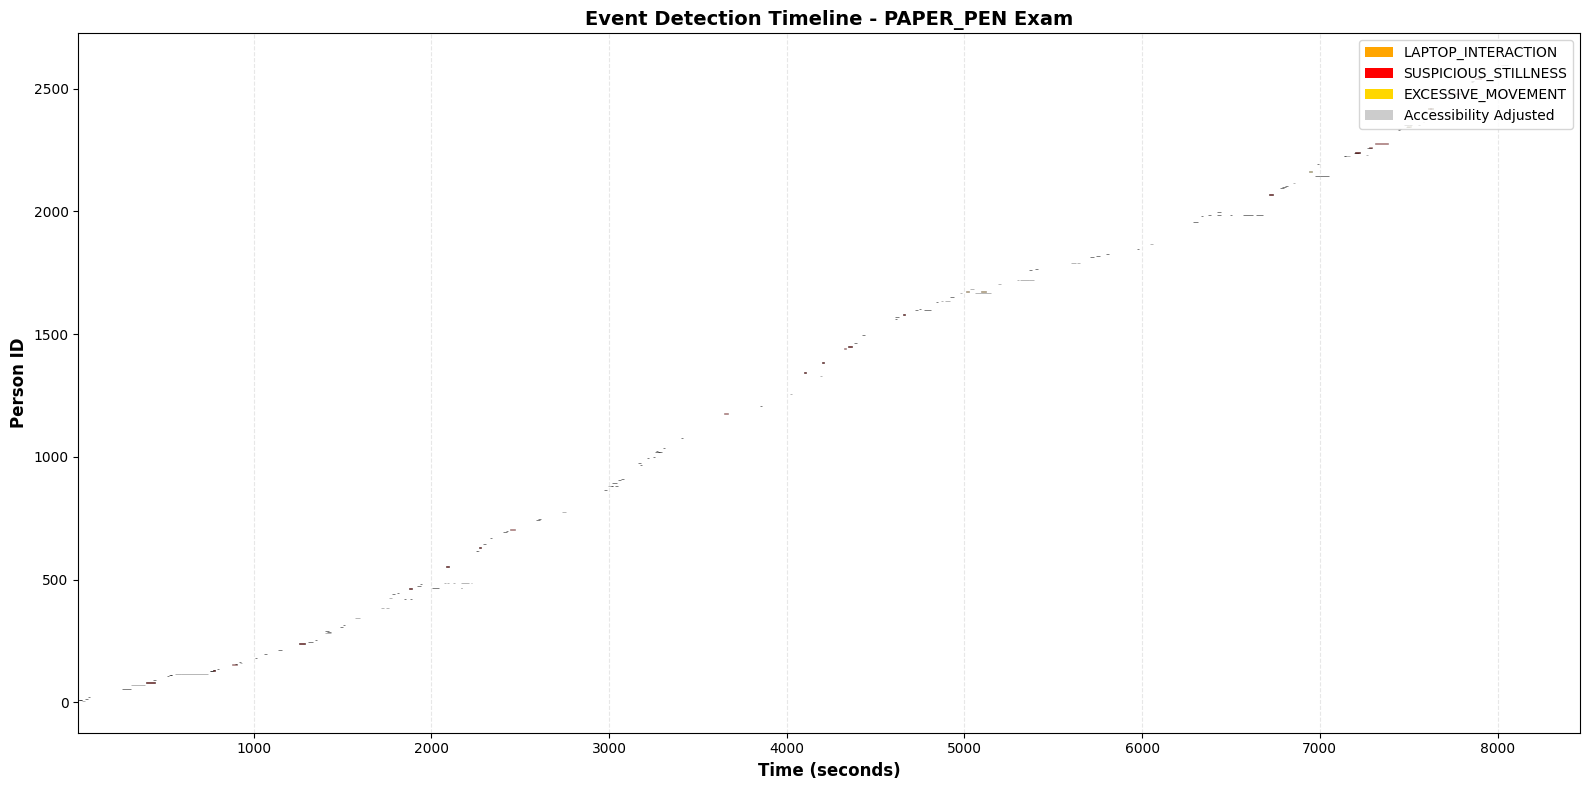

✅ Timeline saved: /content/drive/MyDrive/exam/examlens_phase2_events/event_timeline.png


In [ ]:

# CELL 11: Visualize Event Timeline
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("📊 VISUALIZING EVENT TIMELINE")
print("="*60)

if len(filtered_events) > 0:
    fig, ax = plt.subplots(figsize=(16, 8))

    color_map = {
        'LAPTOP_INTERACTION': 'orange',
        'SUSPICIOUS_STILLNESS': 'red',
        'EXCESSIVE_MOVEMENT': 'gold'
    }

    for event in filtered_events:
        color = color_map.get(event['event_type'], 'gray')
        y_pos = event['person_id']

        # Check if accessibility adjustment
        alpha = 0.4 if event.get('accessibility_adjustment', {}).get('applied') else 0.7

        ax.barh(y_pos, event['duration'], left=event['start_time'],
                height=0.8, color=color, alpha=alpha,
                edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Person ID', fontsize=12, fontweight='bold')
    ax.set_title(f'Event Detection Timeline - {EXAM_TYPE} Exam', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=event_type) for event_type, color in color_map.items()]
    legend_elements.append(Patch(facecolor='gray', alpha=0.4, label='Accessibility Adjusted'))
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

    plt.tight_layout()
    timeline_path = f"{PHASE2_OUTPUT_DIR}event_timeline.png"
    plt.savefig(timeline_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Timeline saved: {timeline_path}")
    shutil.copy(timeline_path, f"{drive_output}event_timeline.png")
else:
    print("⚠️  No events to visualize")

print("="*60)



🔥 GENERATING MOTION HEATMAP
📹 Video size: 1280x720
🔥 Accumulating activity from 9854 frames...


Building heatmap: 100%|██████████| 9854/9854 [00:02<00:00, 3958.44it/s]


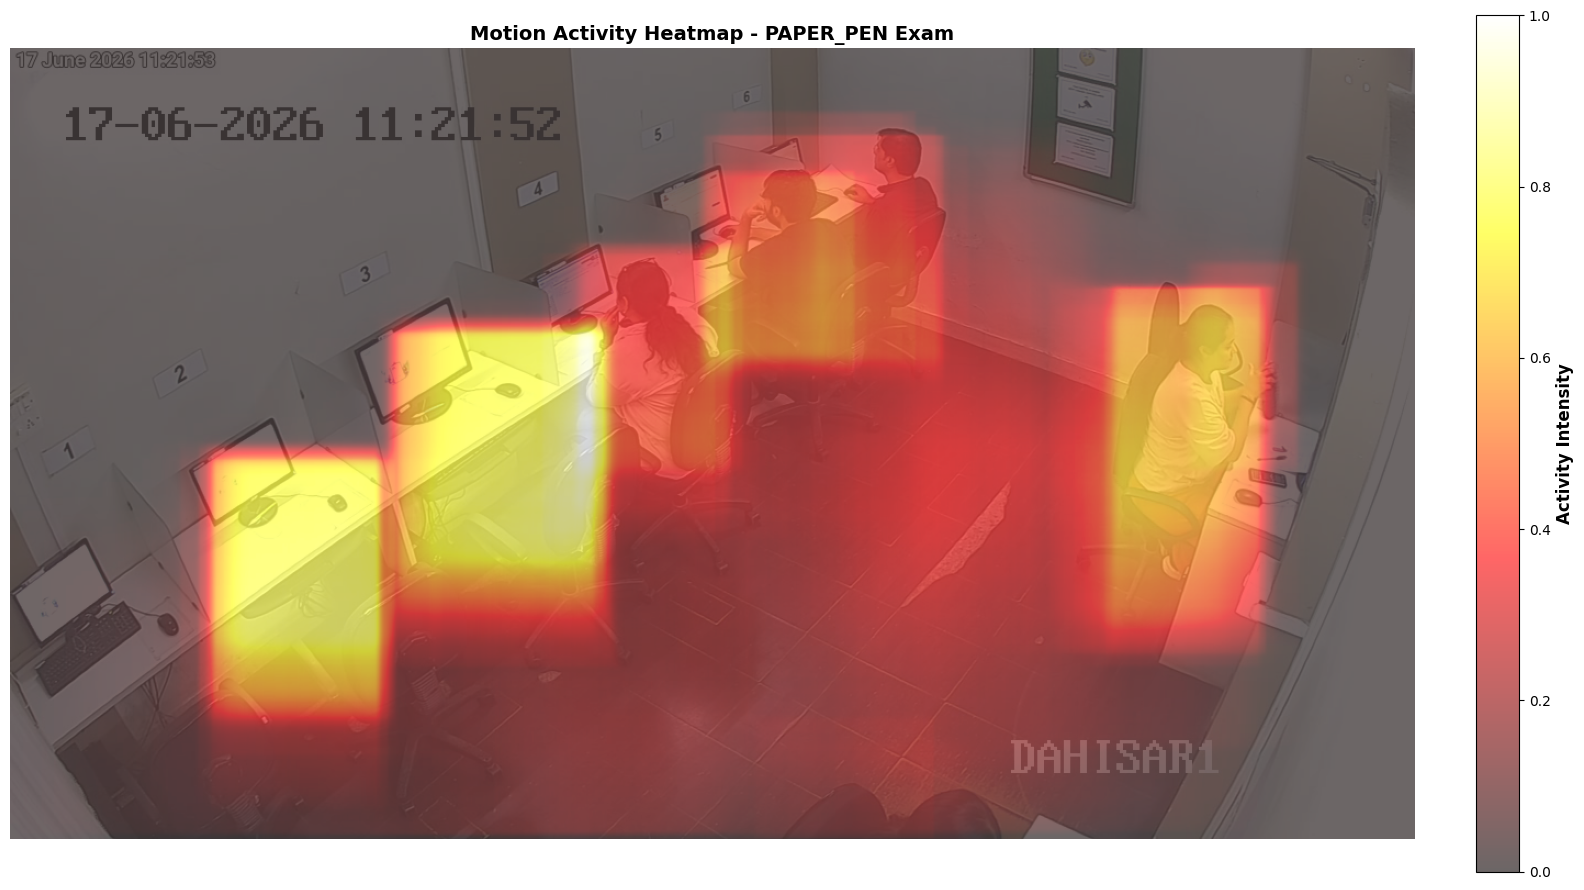

✅ Heatmap saved: /content/drive/MyDrive/exam/examlens_phase2_events/motion_heatmap.png
✅ Heatmap backed up to Drive


In [ ]:
# CELL 14: Generate Motion Heatmap (NEW)
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔥 GENERATING MOTION HEATMAP")
print("="*60)

# Load video dimensions
cap = cv2.VideoCapture(VIDEO_PATH)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ret, first_frame = cap.read()
cap.release()

print(f"📹 Video size: {width}x{height}")

# Create heatmap
heatmap = np.zeros((height, width), dtype=np.float32)

print(f"🔥 Accumulating activity from {len(tracking_data)} frames...")

for frame_data in tqdm(tracking_data, desc="Building heatmap"):
    for det in frame_data['detections']:
        if det['class'] == 'person':
            x1, y1, x2, y2 = map(int, det['bbox'])
            motion_score = det.get('motion_score', 0.5)

            x1, x2 = max(0, x1), min(width, x2)
            y1, y2 = max(0, y1), min(height, y2)

            heatmap[y1:y2, x1:x2] += motion_score

if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

# Visualize
fig, ax = plt.subplots(figsize=(16, 9))

if ret and first_frame is not None:
    first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    ax.imshow(first_frame_rgb, alpha=0.5)

im = ax.imshow(heatmap, cmap='hot', alpha=0.6, interpolation='bilinear')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Activity Intensity', fontsize=12, fontweight='bold')

ax.set_title(f'Motion Activity Heatmap - {EXAM_TYPE} Exam', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
heatmap_path = f"{PHASE2_OUTPUT_DIR}motion_heatmap.png"
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Heatmap saved: {heatmap_path}")

# Save data
heatmap_data = {
    'exam_type': EXAM_TYPE,
    'width': width,
    'height': height,
    'max_value': float(heatmap.max()),
    'min_value': float(heatmap.min())
}

heatmap_json_path = f"{PHASE2_OUTPUT_DIR}heatmap_data.json"
with open(heatmap_json_path, 'w') as f:
    json.dump(heatmap_data, f, indent=2)

shutil.copy(heatmap_path, drive_output)
shutil.copy(heatmap_json_path, drive_output)

print("✅ Heatmap backed up to Drive")
print("="*60)



In [ ]:

# CELL 15: Generate Investigation Report (NEW)
#----------------------------------------------------------------------------
print("\n" + "="*60)
print("📄 GENERATING INVESTIGATION REPORT")
print("="*60)

report = {
    "exam_info": {
        "exam_type": EXAM_TYPE,
        "exam_description": EXAM_PROFILE['description']
    },
    "video_info": {
        "filename": VIDEO_PATH.split('/')[-1],
        "total_frames": len(tracking_data),
        "duration_seconds": tracking_data[-1]['timestamp'] if len(tracking_data) > 0 else 0,
        "resolution": f"{width}x{height}"
    },
    "processing_summary": {
        "persons_tracked": len(person_tracks),
        "total_detections": summary['total_detections'],
        "accessibility_cases": len(accessibility_profiles)
    },
    "events_summary": {
        "total_events": len(filtered_events),
        "high_severity": len([e for e in filtered_events if e['severity'] == 'HIGH']),
        "medium_severity": len([e for e in filtered_events if e['severity'] == 'MEDIUM']),
        "by_type": dict(event_summary)
    },
    "investigation_priority": {
        "immediate_review": [
            {
                "event_id": e['event_id'],
                "type": e['event_type'],
                "person": e['person_id'],
                "time": e['start_time_formatted'],
                "duration": f"{e['duration']:.1f}s",
                "confidence": f"{e['confidence']:.2f}"
            }
            for e in filtered_events if e['severity'] == 'HIGH'
        ][:10],
        "secondary_review": [
            {
                "event_id": e['event_id'],
                "type": e['event_type'],
                "person": e['person_id'],
                "time": e['start_time_formatted']
            }
            for e in filtered_events if e['severity'] == 'MEDIUM'
        ][:10]
    },
    "recommendations": {
        "manual_review_required": len([e for e in filtered_events if e['severity'] == 'HIGH']),
        "estimated_review_time_minutes": len(filtered_events) * 2,
        "attention_persons": list(set([e['person_id'] for e in filtered_events if e['severity'] == 'HIGH']))
    },
    "accessibility_notes": {
        "persons_with_needs": len(accessibility_profiles),
        "adjustments_applied": sum(1 for e in filtered_events if e.get('accessibility_adjustment', {}).get('applied', False))
    }
}

report_path = f"{PHASE2_OUTPUT_DIR}investigation_report.json"
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

shutil.copy(report_path, drive_output)

print(f"✅ Report saved: {report_path}")
print("\n📊 Investigation Summary:")
print(f"   Exam Type: {EXAM_TYPE}")
print(f"   Total Events: {report['events_summary']['total_events']}")
print(f"   HIGH Severity: {report['events_summary']['high_severity']}")
print(f"   MEDIUM Severity: {report['events_summary']['medium_severity']}")
print(f"   Accessibility Cases: {report['accessibility_notes']['persons_with_needs']}")
print(f"   Estimated Review Time: {report['recommendations']['estimated_review_time_minutes']} minutes")
print(f"   Persons Requiring Attention: {len(report['recommendations']['attention_persons'])}")

print("\n" + "="*60)
print("✅ PHASE 2 COMPLETE!")
print("="*60)
print(f"\n📁 Output files saved to:")
print(f"   Local: {PHASE2_OUTPUT_DIR}")
print(f"   Drive: {drive_output}")
print(f"\n🎯 Files generated:")
print(f"   1. events.json (all detected events)")
print(f"   2. event_timeline.png (visual timeline)")
print(f"   3. motion_heatmap.png (spatial activity map)")
print(f"   4. heatmap_data.json (heatmap metadata)")
print(f"   5. investigation_report.json (summary report)")
print(f"\n💡 Next: Share {drive_output} folder with your teammate!")
print("="*60)




📄 GENERATING INVESTIGATION REPORT
✅ Report saved: /content/drive/MyDrive/exam/examlens_phase2_events/investigation_report.json

📊 Investigation Summary:
   Exam Type: PAPER_PEN
   Total Events: 170
   HIGH Severity: 163
   MEDIUM Severity: 7
   Accessibility Cases: 89
   Estimated Review Time: 340 minutes
   Persons Requiring Attention: 136

✅ PHASE 2 COMPLETE!

📁 Output files saved to:
   Local: /content/drive/MyDrive/exam/examlens_phase2_events/
   Drive: /content/drive/MyDrive/exam/phase2_output/

🎯 Files generated:
   1. events.json (all detected events)
   2. event_timeline.png (visual timeline)
   3. motion_heatmap.png (spatial activity map)
   4. heatmap_data.json (heatmap metadata)
   5. investigation_report.json (summary report)

💡 Next: Share {drive_output} folder with your teammate!
